In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_excel('data.xls',index_col=0).reset_index().drop(columns=['index','NI','INF','TCP','EPS'])

In [4]:
df

,name,year,P,SIZE,ROE,ROA,DE,EX,IPE
0,BCE,2018,8.207947,7.16,0.10,0.03,2.53,22602.05,10.58
1,BCE,2019,8.546752,6.75,0.10,0.04,1.33,23050.24,8.98
2,BCE,2020,9.357035,6.84,0.09,0.04,1.62,23208.37,11.58
3,BCE,2021,9.746834,6.70,0.06,0.03,1.06,23159.78,26.72
4,BCE,2022,8.634087,6.47,-0.17,-0.09,0.95,23271.21,10.02
...,...,...,...,...,...,...,...,...,...
160,VSI,2018,9.659503,6.55,0.11,0.03,2.38,22602.05,10.58
161,VSI,2019,9.629708,6.52,0.11,0.03,2.24,23050.24,8.98
162,VSI,2020,9.373309,6.49,0.09,0.03,2.20,23208.37,11.58
163,VSI,2021,9.790879,6.28,0.23,0.09,1.46,23159.78,26.72


In [5]:
df=df.set_index(['name','year'])

In [6]:
df.describe()

,P,SIZE,ROE,ROA,DE,EX,IPE
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,9.407112,7.740182,0.069273,0.030303,2.196303,23058.330000,13.576000
std,0.867018,1.371916,0.213066,0.050911,1.689029,240.052118,6.645773
min,7.064759,5.240000,-2.110000,-0.250000,0.030000,22602.050000,8.980000
25%,8.899731,6.700000,0.030000,0.010000,0.950000,23050.240000,10.020000
50%,9.472243,7.520000,0.080000,0.030000,1.940000,23159.780000,10.580000
75%,9.910463,8.710000,0.130000,0.040000,3.060000,23208.370000,11.580000
max,11.611050,10.480000,0.340000,0.250000,11.790000,23271.210000,26.720000


<Axes: >

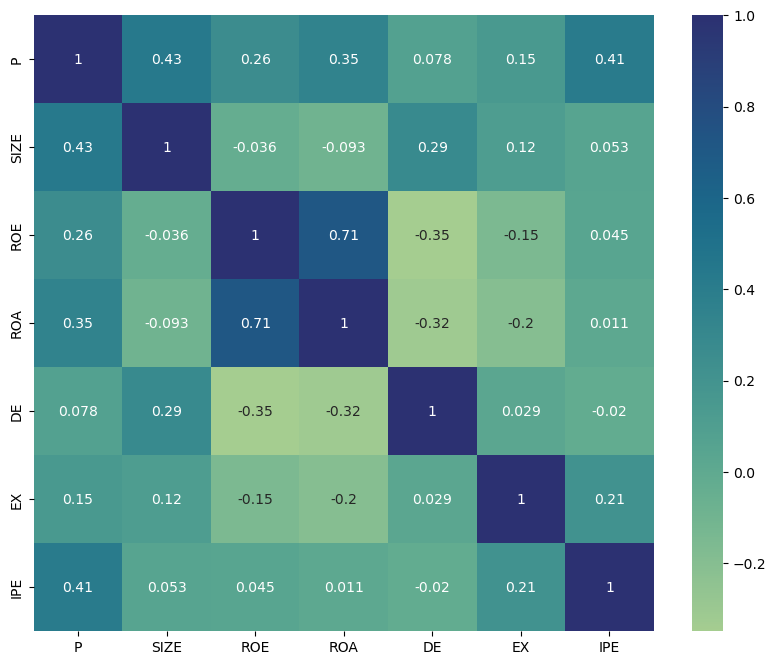

In [7]:
plt.figure(figsize=[10,8])
sns.heatmap(df.corr(),cmap='crest',annot=True)

In [8]:
df['const']=1

In [9]:
#chia tệp dữ liệu
X=df.drop(columns=['P'])
y=df.P

## Mô hình

In [10]:
import statsmodels.api as sm
from linearmodels.panel import PooledOLS

model_pooled_ols = PooledOLS(y,X)
pooled_res = model_pooled_ols.fit()
print(pooled_res)

                          PooledOLS Estimation Summary                          
Dep. Variable:                      P   R-squared:                        0.5021
Estimator:                  PooledOLS   R-squared (Between):              0.5248
No. Observations:                 165   R-squared (Within):               0.4596
Date:                Sun, Jun 30 2024   R-squared (Overall):              0.5021
Time:                        21:31:47   Log-likelihood                   -152.55
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      26.556
Entities:                          33   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(6,158)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             26.556
                            

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Tính VIF cho từng biến độc lập
vif_data = pd.DataFrame({'Biến':X.columns.to_list(),'Hệ số VIF':[variance_inflation_factor(X, i) for i in range(0,X.shape[1])]})
vif_data.head(-1)

,Biến,Hệ số VIF
0,SIZE,1.116840
1,ROE,2.132436
2,ROA,2.101057
3,DE,1.260411
4,EX,1.109160
5,IPE,1.054846


In [13]:
Pearson=df.corr().P.tail(-1)
Pearson.head(-1)

SIZE    0.431599
ROE     0.258785
ROA     0.346123
DE      0.077849
EX      0.149052
IPE     0.412281
Name: P, dtype: float64

Mô hình không có đa cộng tuyến

In [12]:
import statsmodels.api as sm

# Kiểm tra tự tương quan chuỗi bậc nhất
durbin_watson_statistic = sm.stats.stattools.durbin_watson(pooled_res.resids)
print("Giá trị Durbin-Watson:", durbin_watson_statistic)


Giá trị Durbin-Watson: 0.9172346792511914


In [14]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

test_stat, p_value, _, _ = het_white(pooled_res.resids, X)

print(f"Test Statistic: {test_stat}")
print(f"P-value: {p_value}")

Test Statistic: 70.02580375199258
P-value: 6.5774320005854174e-06


OLS có PSSSTĐ + tự tương quan

## Mô hình FEM

In [15]:
from linearmodels import PanelOLS

FEM = PanelOLS(y, X, entity_effects=True)
fe_res = FEM.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:                      P   R-squared:                        0.5766
Estimator:                   PanelOLS   R-squared (Between):              0.3219
No. Observations:                 165   R-squared (Within):               0.5766
Date:                Sun, Jun 30 2024   R-squared (Overall):              0.4105
Time:                        21:31:47   Log-likelihood                   -52.083
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      28.596
Entities:                          33   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(6,126)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             28.596
                            

## Mô hình REM

In [16]:
from linearmodels.panel import RandomEffects

REM = RandomEffects(y,X)
re_res = REM.fit()
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:                      P   R-squared:                        0.5380
Estimator:              RandomEffects   R-squared (Between):              0.3874
No. Observations:                 165   R-squared (Within):               0.5705
Date:                Sun, Jun 30 2024   R-squared (Overall):              0.4511
Time:                        21:31:47   Log-likelihood                   -75.391
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      30.669
Entities:                          33   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(6,158)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             30.669
                            

In [17]:
from linearmodels.panel import compare

print(compare({"Pooled_OLS": pooled_res,"FEM": fe_res, "REM": re_res}))

                            Model Comparison                           
                            Pooled_OLS            FEM               REM
-----------------------------------------------------------------------
Dep. Variable                        P              P                 P
Estimator                    PooledOLS       PanelOLS     RandomEffects
No. Observations                   165            165               165
Cov. Est.                   Unadjusted     Unadjusted        Unadjusted
R-squared                       0.5021         0.5766            0.5380
R-Squared (Within)              0.4596         0.5766            0.5705
R-Squared (Between)             0.5248         0.3219            0.3874
R-Squared (Overall)             0.5021         0.4105            0.4511
F-statistic                     26.556         28.596            30.669
P-value (F-stat)                0.0000         0.0000            0.0000
=====================     ============   ============   ========

In [18]:
#Kiểm định Hausman
from scipy.stats import chi2#nhập thống kê chi bình phương

b_FE = fe_res.params
b_RE = re_res.params
var_FE = fe_res.cov
var_RE = re_res.cov

# Tính toán Hausman test
diff = b_FE - b_RE
cov_diff = var_FE - var_RE
statistic = diff.T @ np.linalg.inv(cov_diff) @ diff
de = len(b_FE)

# Tính p-value
p_value = 1 - chi2.cdf(statistic, de)

# In kết quả
print("Hausman Test Statistic:", statistic)
print("Degrees of Freedom:", de)
print("P-value:", round(p_value,4))

Hausman Test Statistic: 34.486706247194945
Degrees of Freedom: 7
P-value: 0.0


Mô hình FEM phù hợp hơn

In [19]:
#Kiểm định phương sai thay đổi
# Tính toán dư lượng bình phương và tổng cho mỗi nhóm
grouped_residuals_squared = fe_res.resids.groupby(level=0).apply(lambda x: np.sum(x**2))

# Tính trung bình và tổng bình phương
mean_residuals_squared = grouped_residuals_squared.mean()
sum_squared_residuals = np.sum((grouped_residuals_squared - mean_residuals_squared)**2)

# Tính tổng bình phương dư lượng
total_residuals_fourth = np.sum(fe_res.resids**4)

# Wald statistic
W = (len(grouped_residuals_squared) - 1) * sum_squared_residuals / total_residuals_fourth

# Tính p-value
p_value = 1 - chi2.cdf(W, len(grouped_residuals_squared) - 1)

# In kết quả
print('Modified Wald Statistic:', W)
print('P-value:', p_value)

Modified Wald Statistic: 57.686113581910334
P-value: 0.0035491108132329474


In [20]:
import statsmodels.api as sm


# Kiểm tra tự tương quan chuỗi bậc nhất
durbin_watson_statistic = sm.stats.stattools.durbin_watson(fe_res.resids)
print("Giá trị Durbin-Watson:", durbin_watson_statistic)


Giá trị Durbin-Watson: 1.761247138094928


ko có tự tương quan nhưng có pssstd

In [21]:
from statsmodels.regression.linear_model import GLS
import statsmodels.api as sm

# Ước lượng mô hình OLS ban đầu để lấy residuals
ols_res = sm.OLS(y,X).fit()
df['residuals'] = ols_res.resid

# Tính toán trọng số dựa trên residuals (heteroskedasticity)
weights = 1 / df.groupby(level=0)['residuals'].transform(np.var)

# Mô hình FGLS cuối cùng
fgls_model = GLS(y, X, weights=weights)
fgls_results = fgls_model.fit()

print(fgls_results.summary())

                            GLS Regression Results                            
Dep. Variable:                      P   R-squared:                       0.955
Model:                            GLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     564.5
Date:                Sun, 30 Jun 2024   Prob (F-statistic):          5.53e-104
Time:                        21:31:47   Log-Likelihood:                -152.55
No. Observations:                 165   AIC:                             319.1
Df Residuals:                     158   BIC:                             340.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
SIZE           0.2595      0.037      6.923      0.0

C:\Users\Admin\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


## Kiểm định biến ngoại sinh

H0 : Biến là biến ngoại sinh

H1 : Biến là biến nội sinh

In [22]:
#Tạo df chứa biến trễ
lag_df=df.groupby('name').shift(1)
lag_df.fillna(0,inplace=True)

In [24]:
from linearmodels import IV2SLS, IVGMM, IVGMMCUE, IVLIML

var=[]
wu=[]
wool=[]
for i in ['SIZE','ROA','ROE','DE','EX','IPE']:
    reg2sls=IV2SLS(dependent=df['P'],
                   exog=df[['SIZE','ROA','ROE','DE','EX','IPE','const']].drop(columns=[i]),
                   endog=df[i],
                   instruments=lag_df[i]).fit(cov_type='homoskedastic',debiased=True)
    var_=i
    wu_=reg2sls.wu_hausman().pval
    wool_=reg2sls.wooldridge_regression.pval
    var.append(var_)
    wu.append(wu_)
    wool.append(wool_)
exo_result=pd.DataFrame({'Variables':var,'Wu-Hausman':wu,'Wooldridge':wool})

In [25]:
exo_result

,Variables,Wu-Hausman,Wooldridge
0,SIZE,0.175828,0.173879
1,ROA,0.006954,0.006237
2,ROE,0.047034,0.045312
3,SIZE,0.175828,0.173879
4,DE,0.067219,0.065333
5,EX,0.195932,0.194028
6,IPE,0.800299,0.799967


ROE, ROA là biến nội sinh

# Các tham số optional của mô hình

onestep: one-step GMM estimation rather than the default two-step GMM estimation.

iterated: perform iterative GMM estimation.

nolevel: only perform difference GMM

timedumm: automatically include time dummies in part 1, and IV statement in part 2.

collapse: collapse instruments to reduce the problem of too many instruments

In [28]:
from  pydynpd import regression

command_str='P L(1:1).P SIZE ROE ROA DE EX IPE | gmm(ROE ROA , 1:1)  iv(L(1:1).P SIZE DE EX IPE) | collapse '
mydpd = regression.abond(command_str, df.reset_index(), ['name', 'year'])


 Dynamic panel-data estimation, two-step system GMM
 Group variable: name                             Number of obs = 99      
 Time variable: year                              Min obs per group: 3    
 Number of instruments = 10                       Max obs per group: 3    
 Number of groups = 33                            Avg obs per group: 3.00 
+------+------------+---------------------+------------+-----------+-----+
|  P   |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------+------------+---------------------+------------+-----------+-----+
| L1.P | 0.3022822  |      0.0555170      | 5.4448608  | 0.0000001 | *** |
| SIZE | 0.1484147  |      0.0518126      | 2.8644512  | 0.0041773 |  ** |
| ROE  | -0.0994045 |      0.2486542      | -0.3997701 | 0.6893258 |     |
| ROA  | 7.0824132  |      1.6790098      | 4.2182083  | 0.0000246 | *** |
|  DE  | 0.0571670  |      0.0287607      | 1.9876775  | 0.0468474 |  *  |
|  EX  | 0.0006005  |      0.0003967      | 1.51